# ProQuest TDM Archive — Descriptive Overview

This notebook loads all `.csv.gz` exports from ProQuest TDM Studio (expected under `/data/mourad/narratives/proquest/raw_from_TDM/`) and surfaces summary statistics about article coverage, source diversity, and document lengths. Update `DATA_DIR` below if the files live somewhere else.

## Notebook goals

- Inspect available exports and confirm schema
- Combine the files into a single DataFrame
- Produce yearly article and source counts
- Highlight top publications and datelines
- Explore article length distributions

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.options.display.max_rows = 50
pd.options.display.max_columns = 20

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 5)


In [16]:
DATA_DIR = Path("/data/mourad/narratives/proquest/raw_from_TDM")

if not DATA_DIR.exists():
    print(f"Warning: {DATA_DIR} was not found. Falling back to /data/mourad/narratives/proquest")
    DATA_DIR = Path("/data/mourad/narratives/proquest")

csv_paths = sorted(DATA_DIR.glob("*.csv.gz"))

if not csv_paths:
    raise FileNotFoundError(f"No .csv.gz exports found in {DATA_DIR}")

file_info = pd.DataFrame(
    {
        "filename": [path.name for path in csv_paths],
        "size_mb": [round(path.stat().st_size / 1024**2, 2) for path in csv_paths],
    }
).sort_values("filename")

display(file_info)
print(f"Total files discovered: {len(csv_paths)}")


,filename,size_mb
0,local-data.csv.gz,222.6


Total files discovered: 1


In [3]:
def load_proquest_csvs(paths, usecols=None):
    frames = []
    for path in paths:
        print(f"Loading {path.name} ...")
        df = pd.read_csv(
            path,
            sep="	",
            compression="infer",
            usecols=usecols,
            dtype="string",
            on_bad_lines="skip",
        )
        df["source_file"] = path.name
        frames.append(df)

    if not frames:
        raise ValueError("No frames were loaded; check the glob pattern or file permissions.")

    return pd.concat(frames, ignore_index=True)


In [4]:
columns_to_keep = ["file_id", "year_month", "title", "loc", "text"]
articles = load_proquest_csvs(csv_paths, usecols=columns_to_keep)

articles = articles.rename(columns={"file_id": "article_id", "title": "source_title"})

articles["article_id"] = articles["article_id"].astype("string")
articles["source_title"] = articles["source_title"].str.strip()
articles["loc"] = articles["loc"].str.strip()

articles["year_month"] = pd.to_datetime(articles["year_month"], format="%Y-%m", errors="coerce")
articles["year"] = articles["year_month"].dt.year
articles["month"] = articles["year_month"].dt.month

articles["word_count"] = (
    articles["text"]
    .fillna("")
    .str.split()
    .map(len)
)

print(f"Combined rows: {len(articles):,}")
display(articles.head())


Loading local-data.csv.gz ...
Combined rows: 992,618


,article_id,year_month,source_title,loc,text,source_file,year,month,word_count
0,1876568450,1968-02-01,Minneapolis Tribune (1964-1982),Minneapolis,Fowler said higher taxes are needed now to hal...,local-data.csv.gz,1968,2,16
1,1832235278,1993-09-01,Los Angeles Times (1923-1995),"Los Angeles, Calif.",Gold Oil Lead Market Plunge Dow Falls 26 From ...,local-data.csv.gz,1993,9,497
2,1901304066,1972-04-01,St. Louis Post-Dispatch (1923-),St Louis,"Because he is young and inflation is rampant, ...",local-data.csv.gz,1972,4,23
3,1879829530,1983-04-01,Minneapolis Star and Tribune (1982-1987),Minneapolis,Women plot to rob a shopping center to help ke...,local-data.csv.gz,1983,4,13
4,1888671555,1975-09-01,Cincinnati Enquirer (1923-),Cincinnati,"Call Mr. Bradley, 793-2544, in complete confid...",local-data.csv.gz,1975,9,26


In [5]:
date_min = articles["year_month"].min()
date_max = articles["year_month"].max()

summary_rows = [
    ("Rows", f"{len(articles):,}"),
    ("Unique articles", f"{articles['article_id'].nunique(dropna=True):,}"),
    ("Unique sources", f"{articles['source_title'].nunique(dropna=True):,}"),
    ("Unique locations", f"{articles['loc'].nunique(dropna=True):,}"),
    (
        "Date range",
        f"{date_min.date()} — {date_max.date()}" if pd.notna(date_min) and pd.notna(date_max) else "Not available",
    ),
    ("Missing year_month values", f"{articles['year_month'].isna().sum():,}"),
]

summary_df = pd.DataFrame(summary_rows, columns=["metric", "value"])
display(summary_df)


,metric,value
0,Rows,"992,618"
1,Unique articles,"581,380"
2,Unique sources,45
3,Unique locations,21
4,Date range,1960-01-01 — 2010-01-01
5,Missing year_month values,0


In [6]:
yearly = (
    articles.dropna(subset=["year"])
    .groupby("year")
    .agg(
        total_records=("article_id", "size"),
        unique_articles=("article_id", "nunique"),
        unique_sources=("source_title", "nunique"),
        mean_word_count=("word_count", "mean"),
        median_word_count=("word_count", "median"),
    )
    .reset_index()
    .sort_values("year")
)

display(yearly)


,year,total_records,unique_articles,unique_sources,mean_word_count,median_word_count
0,1960,6410,4450,27,72.167707,28.0
1,1961,4150,2966,25,68.933976,28.0
2,1962,3915,2886,26,77.069221,28.0
3,1963,2960,2146,23,33.848311,26.0
4,1964,3850,2712,24,37.035325,27.0
...,...,...,...,...,...,...
46,2006,5362,3125,17,144.446102,32.0
47,2007,4759,2827,17,153.318975,31.0
48,2008,5775,3527,17,156.499048,32.0
49,2009,1999,1323,15,120.349675,30.0


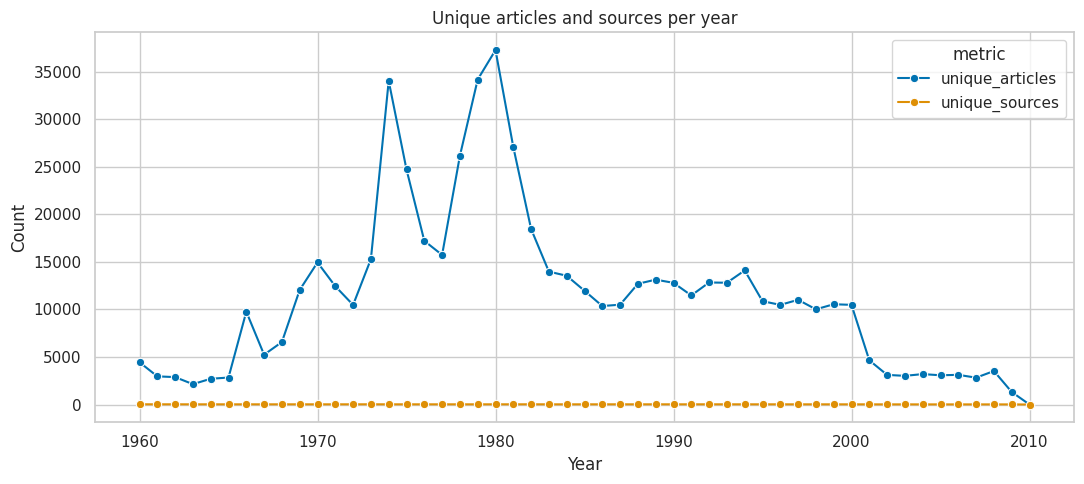

In [7]:
yearly_melted = yearly.melt(
    id_vars="year",
    value_vars=["unique_articles", "unique_sources"],
    var_name="metric",
    value_name="count",
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=yearly_melted, x="year", y="count", hue="metric", marker="o", ax=ax)
ax.set_title("Unique articles and sources per year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


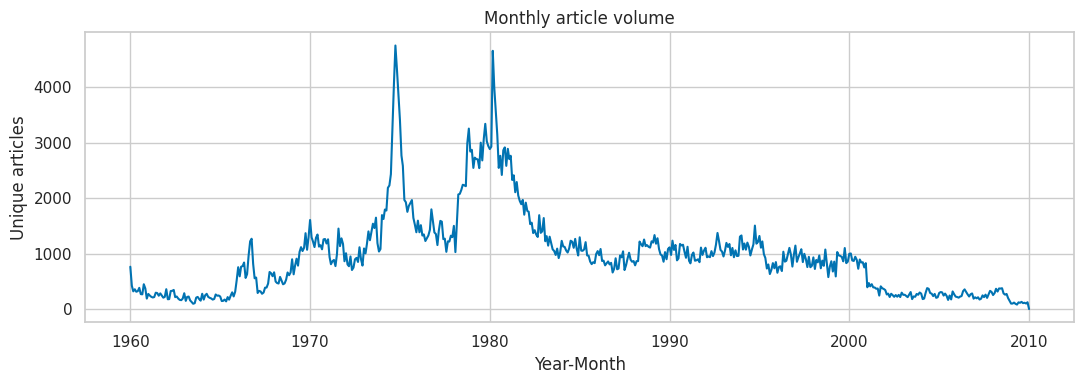

In [8]:
monthly = (
    articles.dropna(subset=["year_month"])
    .groupby("year_month")["article_id"]
    .nunique()
    .reset_index(name="unique_articles")
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=monthly, x="year_month", y="unique_articles", ax=ax)
ax.set_title("Monthly article volume")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Unique articles")
plt.tight_layout()
plt.show()


In [9]:
top_sources = (
    articles.groupby("source_title")["article_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(25)
    .reset_index()
    .rename(columns={"article_id": "unique_articles"})
)

display(top_sources)


,source_title,unique_articles
0,Los Angeles Times (1923-1995),87861
1,Chicago Tribune (1963-1996),61614
2,St. Louis Post-Dispatch (1923-),50422
3,Cincinnati Enquirer (1923-),46839
4,Indianapolis Star (1923-),45324
5,Detroit Free Press (1923-),37597
6,Boston Globe (1960-),33048
7,Courier-Journal (1923-) The,31938
8,Tennessean (1972-) The,28970
9,Minneapolis Tribune (1964-1982),28316


In [10]:
top_sources_by_year = (
    articles.dropna(subset=["year"])
    .groupby(["year", "source_title"])["article_id"]
    .nunique()
    .reset_index(name="unique_articles")
)

if top_sources_by_year.empty:
    print("No valid year/source combinations found.")
else:
    max_year = top_sources_by_year["year"].max()
    recent_slice = top_sources_by_year[top_sources_by_year["year"] >= max_year - 9]
    top_sources_recent = (
        recent_slice
        .sort_values(["year", "unique_articles"], ascending=[True, False])
        .groupby("year")
        .head(10)
    )
    display(top_sources_recent)


,year,source_title,unique_articles
996,2001,Chicago Tribune (1997-),1273
1008,2001,Star Tribune (1987-),676
995,2001,Chicago Tribune,598
1007,2001,St. Louis Post-Dispatch (1923-),544
997,2001,Cincinnati Enquirer (1923-),454
...,...,...,...
1140,2009,Los Angeles Sentinel (1934-),9
1145,2009,New York Amsterdam News (1962-),6
1133,2009,Afro-American (1893-),5
1148,2010,Chicago Tribune,1


In [11]:
top_locations = (
    articles["loc"]
    .dropna()
    .value_counts()
    .head(25)
    .rename_axis("loc")
    .reset_index(name="article_mentions")
)

display(top_locations)


,loc,article_mentions
0,"Chicago, Ill.",192075
1,"Los Angeles, Calif.",151849
2,Minneapolis,120437
3,St Louis,93200
4,Cincinnati,83557
5,Indianapolis,80114
6,Detroit,66967
7,Nashville,58204
8,Louisville,56929
9,"Boston, Mass.",44757


,word_count_stats
count,992618.000000
mean,92.439336
std,222.410280
min,0.000000
10%,13.000000
25%,20.000000
50%,30.000000
75%,47.000000
90%,229.000000
max,21603.000000


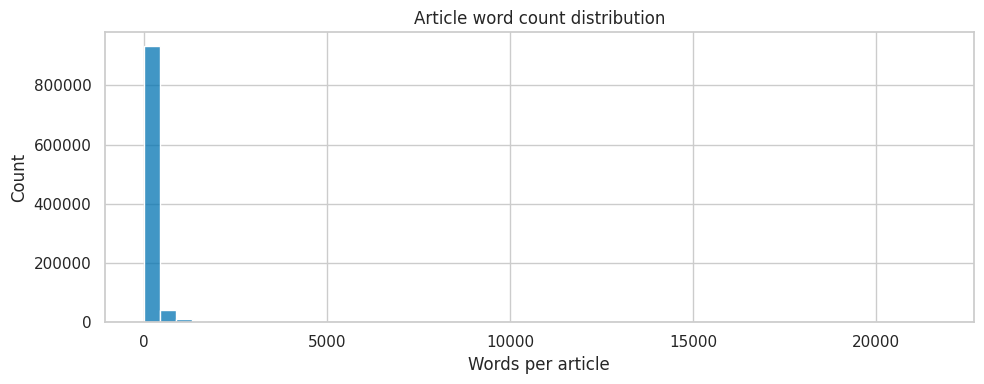

In [12]:
word_stats = articles["word_count"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame(name="word_count_stats")
display(word_stats)

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(articles["word_count"].dropna(), bins=50, ax=ax)
ax.set_title("Article word count distribution")
ax.set_xlabel("Words per article")
plt.tight_layout()
plt.show()


In [13]:
# Optional: export summary tables for downstream analysis
OUTPUT_DIR = Path("src/preprocess/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

yearly.to_csv(OUTPUT_DIR / "proquest_articles_by_year.csv", index=False)
top_sources.to_csv(OUTPUT_DIR / "proquest_top_sources.csv", index=False)
monthly.to_csv(OUTPUT_DIR / "proquest_articles_by_month.csv", index=False)

print(f"Exported summary tables to {OUTPUT_DIR.resolve()}")


Exported summary tables to /home/mourad/causal-micro-narratives/src/preprocess/src/preprocess/output
